# Explainable AI for Breast Cancer Detection Using Mammograms

**ECS7036P Project — Eric Kamalendran**

End-to-end notebook implementing the project proposal on the **CBIS-DDSM**
dataset:

1. Data loading & patient-level train/val/test split
2. Preprocessing (artefact removal, CLAHE, resize, augmentation)
3. **Baseline**: ResNet50 image-only classifier
4. **Multimodal**: ResNet50 image features + structured clinical data (feature-level fusion)
5. **Explainability**: Grad-CAM (image regions) + SHAP (clinical features)
6. **Evaluation**: Accuracy, Precision, Recall, Specificity, F1, ROC-AUC, confusion matrix, ROC curve — with Recall emphasised to minimise false negatives



## 1. Setup

In [1]:
# If running on Colab, uncomment to install dependencies
# !pip install -q torch torchvision scikit-learn opencv-python-headless shap tqdm

import os, random, time
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())

# Speeds up convolutions once input sizes are fixed (they are: 224x224) —
# lets cuDNN pick the fastest algorithm for the T4 after a short warm-up.
torch.backends.cudnn.benchmark = True


Torch: 2.11.0+cu128 | CUDA available: True


In [2]:
# (Optional) Mount Google Drive if your CBIS-DDSM download lives there
# from google.colab import drive
# drive.mount('/content/drive')


## 2. Configuration

Download the preprocessed JPEG CBIS-DDSM export from Kaggle:
https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset




In [3]:
# Locate (or download) the CBIS-DDSM dataset automatically


import glob

def find_dataset_root(search_roots=None):
    """Searches common locations for an already-downloaded copy of the
    dataset by looking for one of its known CSV files, then returns the
    folder two levels up (the dataset root, containing csv/ and jpeg/)."""
    search_roots = search_roots or [
        "/content", "/kaggle/input",
        os.path.expanduser("~/.cache/kagglehub"), ".",
    ]
    for root in search_roots:
        if not os.path.exists(root):
            continue
        matches = glob.glob(
            os.path.join(root, "**", "mass_case_description_train_set.csv"),
            recursive=True,
        )
        if matches:
            csv_dir = os.path.dirname(matches[0])
            return os.path.dirname(csv_dir)
    return None


def download_dataset_via_kagglehub():
    """Downloads the dataset via kagglehub. Requires Kaggle credentials —
    on Colab, either upload kaggle.json to ~/.kaggle/, or set the
    KAGGLE_USERNAME / KAGGLE_KEY secrets, before running this."""
    try:
        import kagglehub
    except ImportError:
        import subprocess
        subprocess.run(["pip", "install", "-q", "kagglehub"], check=True)
        import kagglehub
    return kagglehub.dataset_download("awsaf49/cbis-ddsm-breast-cancer-image-dataset")


DATA_ROOT = find_dataset_root()
if DATA_ROOT is None:
    print("Dataset not found locally — attempting download via kagglehub "
          "(requires Kaggle API credentials)...")
    downloaded_path = download_dataset_via_kagglehub()
    DATA_ROOT = find_dataset_root([downloaded_path]) or downloaded_path

print("DATA_ROOT (as found):", DATA_ROOT)


def ensure_fast_local_copy(data_root):
    """Some mounts are slow for the thousands of small random image reads
    this pipeline does during caching — Kaggle's read-only /kaggle/input
    (network-backed FUSE) and a mounted Google Drive in Colab
    (/content/drive) are the two common cases. If DATA_ROOT lives on one of
    these, copy it once to fast local disk and use that copy instead.

    The copy itself is parallelised across many threads: these mounts are
    typically latency-bound per file (each open/read has overhead) rather
    than throughput-bound, so a naive sequential copytree barely helps —
    it just moves the same one-file-at-a-time bottleneck to the copy step.
    Many concurrent reads in flight overlap that latency instead.
    """
    from concurrent.futures import ThreadPoolExecutor, as_completed

    slow_mount_prefixes = ("/kaggle/input", "/content/drive")
    if not any(data_root.startswith(p) for p in slow_mount_prefixes):
        return data_root  # already on fast local disk — nothing to do

    local_root = "/kaggle/working/cbis_ddsm_local" if os.path.exists("/kaggle/working") \
        else "/content/cbis_ddsm_local"

    if os.path.exists(local_root):
        print(f"Using existing local copy at {local_root}")
        return local_root

    print(f"DATA_ROOT is on a slow mount ({data_root}).")
    print("Indexing files to copy...")

    file_pairs = []
    for root, _dirs, files in os.walk(data_root):
        rel_root = os.path.relpath(root, data_root)
        dest_dir = os.path.join(local_root, rel_root)
        os.makedirs(dest_dir, exist_ok=True)
        for fname in files:
            file_pairs.append((os.path.join(root, fname), os.path.join(dest_dir, fname)))

    print(f"Copying {len(file_pairs)} files to local disk in parallel "
          f"(this is much faster than a sequential copy for many small files)...")

    def _copy_one(pair):
        src, dst = pair
        with open(src, "rb") as fsrc, open(dst, "wb") as fdst:
            fdst.write(fsrc.read())

    num_workers = 32  # I/O-latency-bound, not CPU-bound — high concurrency helps a lot
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = [executor.submit(_copy_one, pair) for pair in file_pairs]
        for f in tqdm(as_completed(futures), total=len(futures), desc="Copying dataset to local disk"):
            f.result()
    print("Copy complete.")
    return local_root


DATA_ROOT = ensure_fast_local_copy(DATA_ROOT)
print("DATA_ROOT (in use):", DATA_ROOT)

#  Derive CSV file paths and the jpeg/ root by searching, not guessing
def find_file(root, filename):
    matches = glob.glob(os.path.join(root, "**", filename), recursive=True)
    return matches[0] if matches else None

CSV_FILES = [p for p in [
    find_file(DATA_ROOT, "mass_case_description_train_set.csv"),
    find_file(DATA_ROOT, "mass_case_description_test_set.csv"),
    find_file(DATA_ROOT, "calc_case_description_train_set.csv"),
    find_file(DATA_ROOT, "calc_case_description_test_set.csv"),
] if p]

jpeg_dirs = glob.glob(os.path.join(DATA_ROOT, "**", "jpeg"), recursive=True)
JPEG_ROOT = jpeg_dirs[0] if jpeg_dirs else os.path.join(DATA_ROOT, "jpeg")

print(f"Found {len(CSV_FILES)}/4 CSV files:")
for p in CSV_FILES:
    print(" -", p)
print("JPEG_ROOT:", JPEG_ROOT, "| exists:", os.path.isdir(JPEG_ROOT))

if len(CSV_FILES) == 0:
    print("\n[!] No CSVs found automatically. If you downloaded the dataset "
          "somewhere unusual, set DATA_ROOT manually in the next cell and "
          "re-run this cell's CSV_FILES/JPEG_ROOT block.")

#  CBIS-DDSM column names
COL_PATIENT_ID = "patient_id"
COL_PATHOLOGY = "pathology"                 # BENIGN / MALIGNANT / BENIGN_WITHOUT_CALLBACK
COL_IMAGE_PATH = "image file path"          # full mammogram
COL_CROPPED_IMAGE_PATH = "cropped image file path"   # tight crop around the lesion — used for training
COL_BREAST_DENSITY = "breast_density"
COL_MASS_SHAPE = "mass shape"
COL_MASS_MARGINS = "mass margins"
COL_ASSESSMENT = "assessment"
CLINICAL_FEATURE_COLUMNS = [COL_BREAST_DENSITY, COL_MASS_SHAPE, COL_MASS_MARGINS, COL_ASSESSMENT]

#  Preprocessing
IMAGE_SIZE = 224
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

#  Splits
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.7, 0.15, 0.15
RANDOM_SEED = 42

#  Training
BATCH_SIZE = 64          # T4 (16GB) comfortably fits ResNet50 @224px at this size
NUM_WORKERS = min(4, os.cpu_count() or 2)   # Colab typically gives 2 CPU cores
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5
NUM_CLASSES = 2
CLINICAL_HIDDEN_DIM = 64
FUSION_HIDDEN_DIM = 256

#  Output
OUTPUT_DIR = "./outputs"
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
for d in (OUTPUT_DIR, CHECKPOINT_DIR, FIGURES_DIR):
    os.makedirs(d, exist_ok=True)

def set_seed(seed=RANDOM_SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Dataset not found locally — attempting download via kagglehub (requires Kaggle API credentials)...
Using Colab cache for faster access to the 'cbis-ddsm-breast-cancer-image-dataset' dataset.
DATA_ROOT (as found): /kaggle/input/cbis-ddsm-breast-cancer-image-dataset
DATA_ROOT is on a slow mount (/kaggle/input/cbis-ddsm-breast-cancer-image-dataset).
Indexing files to copy...
Copying 10243 files to local disk in parallel (this is much faster than a sequential copy for many small files)...


Copying dataset to local disk:   0%|          | 0/10243 [00:00<?, ?it/s]

Copy complete.
DATA_ROOT (in use): /content/cbis_ddsm_local
Found 4/4 CSV files:
 - /content/cbis_ddsm_local/csv/mass_case_description_train_set.csv
 - /content/cbis_ddsm_local/csv/mass_case_description_test_set.csv
 - /content/cbis_ddsm_local/csv/calc_case_description_train_set.csv
 - /content/cbis_ddsm_local/csv/calc_case_description_test_set.csv
JPEG_ROOT: /content/cbis_ddsm_local/jpeg | exists: True
Using device: cuda


## 3. Preprocessing

Mirrors the proposal: artefact removal, CLAHE contrast enhancement, resize to
224×224, and augmentation (rotation, flip, zoom, brightness) for training.


In [4]:
def remove_artefacts(image: np.ndarray) -> np.ndarray:
    """Keeps only the largest connected bright region (the breast tissue),
    dropping scan labels / borders. Expects a grayscale uint8 image."""
    _, thresh = cv2.threshold(image, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return image
    largest = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(image)
    cv2.drawContours(mask, [largest], -1, 255, thickness=cv2.FILLED)
    return cv2.bitwise_and(image, image, mask=mask)

def apply_clahe(image: np.ndarray) -> np.ndarray:
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID_SIZE)
    return clahe.apply(image)

def preprocess_mammogram(image_path: str) -> np.ndarray:
    """Full pipeline for a single mammogram: artefact removal -> CLAHE ->
    resize -> grayscale-to-RGB (ResNet50 expects 3 channels)."""
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    image = remove_artefacts(image)
    image = apply_clahe(image)
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

def get_train_transforms():
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomRotation(degrees=15),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

def get_eval_transforms():
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


## 4. Load metadata & patient-level split

Splitting by `patient_id` (not by image) ensures no patient appears in more
than one split, preventing data leakage — as specified in the proposal.


In [5]:
LABEL_MAP = {"BENIGN": 0, "BENIGN_WITHOUT_CALLBACK": 0, "MALIGNANT": 1}

def load_metadata() -> pd.DataFrame:
    frames = []
    for path in CSV_FILES:
        if os.path.exists(path):
            frames.append(pd.read_csv(path))
        else:
            print(f"[warn] metadata file not found, skipping: {path}")
    if not frames:
        raise FileNotFoundError(
            "No CBIS-DDSM CSV files found. Set DATA_ROOT above to your downloaded dataset."
        )
    df = pd.concat(frames, ignore_index=True)
    df = df.dropna(subset=[COL_PATHOLOGY, COL_IMAGE_PATH])
    df["label"] = df[COL_PATHOLOGY].str.upper().map(LABEL_MAP)
    df = df.dropna(subset=["label"])
    df["label"] = df["label"].astype(int)
    return df.reset_index(drop=True)

def patient_level_split(df: pd.DataFrame):
    patients = df[COL_PATIENT_ID].unique()
    train_p, temp_p = train_test_split(patients, train_size=TRAIN_FRAC, random_state=RANDOM_SEED)
    relative_val = VAL_FRAC / (VAL_FRAC + TEST_FRAC)
    val_p, test_p = train_test_split(temp_p, train_size=relative_val, random_state=RANDOM_SEED)
    train_df = df[df[COL_PATIENT_ID].isin(train_p)].reset_index(drop=True)
    val_df = df[df[COL_PATIENT_ID].isin(val_p)].reset_index(drop=True)
    test_df = df[df[COL_PATIENT_ID].isin(test_p)].reset_index(drop=True)
    return train_df, val_df, test_df

def fit_clinical_encoder(train_df: pd.DataFrame):
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    cols = [c for c in CLINICAL_FEATURE_COLUMNS if c in train_df.columns]
    encoder.fit(train_df[cols].astype(str))
    return encoder, cols

# Run once your DATA_ROOT above points at a real download:
# df = load_metadata()
# train_df, val_df, test_df = patient_level_split(df)
# print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")


### 4b. Resolving image paths (important — read this)

The CBIS-DDSM CSVs store the **original DICOM file path**, e.g.:

```
Mass-Test_P_00820_RIGHT_CC/1.3.6.1.4.1.9590..../1.3.6.1.4.1.9590..../000000.dcm
```

But the Kaggle JPEG export **renames the files inside each folder** (e.g. to
`1-1.jpg`) — it does not keep `000000.dcm` as `000000.jpg`. So naively
joining `JPEG_ROOT` with the CSV path never matches a real file, which is
what causes `FileNotFoundError: ...000000.dcm` during training.

The fix: the **second-to-last folder** in the CSV path is the DICOM
SeriesInstanceUID, and that folder name is preserved as-is under `jpeg/`.
We scan `jpeg/` once, build a `{UID: [jpg files inside it]}` map, and use
it to resolve every row to its real `.jpg` path.


In [6]:
import glob

def build_uid_to_jpeg_map(jpeg_root):
    """One-time scan of jpeg/: maps each DICOM series-UID folder name to
    the jpg file(s) inside it."""
    uid_map = {}
    for entry in os.scandir(jpeg_root):
        if entry.is_dir():
            jpgs = sorted(glob.glob(os.path.join(entry.path, "*.jpg")))
            if jpgs:
                uid_map[entry.name] = jpgs
    return uid_map


def resolve_image_paths(df, uid_map, path_column):
    """Resolves each row's original .dcm path to the matching real .jpg
    path by looking up the SeriesUID folder (2nd-to-last path component).
    Returns None for rows with no matching folder/jpg.
    """
    resolved = []
    for raw_path in df[path_column]:
        series_uid = str(raw_path).strip().replace("\\\\", "/").split("/")[-2]
        candidates = uid_map.get(series_uid)
        if not candidates:
            resolved.append(None)
        elif len(candidates) == 1:
            resolved.append(candidates[0])
        else:
            # Multiple files in the folder (e.g. cropped image + mask) —
            # the full-resolution mammogram is almost always the largest.
            resolved.append(max(candidates, key=os.path.getsize))
    return resolved


def load_and_resolve(path_column=COL_IMAGE_PATH):
    """Loads metadata, resolves image paths against the actual jpeg/
    folder, and drops any rows that couldn't be matched (reports how many).
    """
    df = load_metadata()
    uid_map = build_uid_to_jpeg_map(JPEG_ROOT)
    df["resolved_image_path"] = resolve_image_paths(df, uid_map, path_column)

    n_before = len(df)
    unmatched = df["resolved_image_path"].isna().sum()
    df = df.dropna(subset=["resolved_image_path"]).reset_index(drop=True)
    print(f"Resolved {len(df)}/{n_before} images "
          f"({unmatched} dropped — no matching jpg found under jpeg/)")
    return df


### 4c. Caching preprocessed images (the single biggest speedup)

Without caching, **every** epoch re-reads each raw mammogram from disk and
re-runs artefact removal + CLAHE + resize on it — that CPU work is far
slower than the T4 needs to process a batch, so the GPU sits idle waiting
on the data loader.

This step preprocesses every image **once**, saves the result as a small
`.npy` array, and every subsequent epoch just loads the cached array
(microseconds) instead of recomputing it. It's a one-time cost, run before
training the baseline, and reused automatically for the multimodal model
in Section 10 since both use the same underlying `df`.


In [7]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def build_image_cache(df, cache_dir="./image_cache", num_workers=None):
    """Preprocesses every image once (artefact removal, CLAHE, resize) and
    caches the result as a .npy file. OpenCV releases the GIL during its
    C++ calls, so a thread pool gives real parallelism here despite Python
    threading, without the pickling headaches of multiprocessing in a
    notebook.
    """
    os.makedirs(cache_dir, exist_ok=True)
    num_workers = num_workers or min(16, (os.cpu_count() or 4) * 4)

    def _process(item):
        idx, src_path = item
        cache_path = os.path.join(cache_dir, f"{idx}.npy")
        if not os.path.exists(cache_path):
            img = preprocess_mammogram(src_path)
            np.save(cache_path, img)
        return idx, cache_path

    items = list(zip(df.index, df["resolved_image_path"]))
    results = {}
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = [executor.submit(_process, item) for item in items]
        for f in tqdm(as_completed(futures), total=len(futures), desc="Caching preprocessed images"):
            idx, cache_path = f.result()
            results[idx] = cache_path

    df = df.copy()
    df["cache_path"] = df.index.map(results)
    return df


## 5. Datasets

In [8]:
class MammogramDataset(Dataset):
    """Image-only dataset for the ResNet50 baseline. Reads pre-processed
    images from the cache built in Section 4c (near-instant) rather than
    re-running artefact removal/CLAHE on every access."""
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = np.load(row["cache_path"])
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row["label"], dtype=torch.long)
        return image, label


class MultimodalMammogramDataset(Dataset):
    """Image + one-hot-encoded clinical feature dataset for the fusion
    model. Also reads pre-processed images from the cache."""
    def __init__(self, df, encoder, clinical_cols, transform=None):
        self.df = df.reset_index(drop=True)
        self.encoder = encoder
        self.clinical_cols = clinical_cols
        self.transform = transform
        self.clinical_features = encoder.transform(self.df[clinical_cols].astype(str)).astype(np.float32)

    def __len__(self):
        return len(self.df)

    @property
    def clinical_feature_dim(self):
        return self.clinical_features.shape[1]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = np.load(row["cache_path"])
        if self.transform:
            image = self.transform(image)
        clinical = torch.tensor(self.clinical_features[idx], dtype=torch.float32)
        label = torch.tensor(row["label"], dtype=torch.long)
        return image, clinical, label


## 6. Models

- **ResNet50Baseline**: transfer-learning image-only classifier
- **ClinicalEncoder**: small MLP encoding structured clinical features
- **MultimodalFusionModel**: feature-level fusion of image + clinical embeddings


In [9]:
class ResNet50Baseline(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = models.resnet50(weights=weights)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)


class ClinicalEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=CLINICAL_HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)


class MultimodalFusionModel(nn.Module):
    def __init__(self, clinical_input_dim, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        backbone = models.resnet50(weights=weights)
        self.image_feature_dim = backbone.fc.in_features
        self.image_encoder = nn.Sequential(*list(backbone.children())[:-1])
        self.clinical_encoder = ClinicalEncoder(clinical_input_dim)
        fusion_input_dim = self.image_feature_dim + CLINICAL_HIDDEN_DIM
        self.classifier = nn.Sequential(
            nn.Linear(fusion_input_dim, FUSION_HIDDEN_DIM), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(FUSION_HIDDEN_DIM, num_classes),
        )

    def forward(self, image, clinical):
        img_feats = torch.flatten(self.image_encoder(image), 1)
        clin_feats = self.clinical_encoder(clinical)
        fused = torch.cat([img_feats, clin_feats], dim=1)
        return self.classifier(fused)


def build_model(mode, clinical_input_dim=None):
    if mode == "baseline":
        return ResNet50Baseline()
    elif mode == "multimodal":
        if clinical_input_dim is None:
            raise ValueError("clinical_input_dim required for multimodal model")
        return MultimodalFusionModel(clinical_input_dim)
    raise ValueError(f"Unknown mode: {mode}")


## 7. Training loop

In [10]:
class EarlyStopping:
    def __init__(self, patience=EARLY_STOPPING_PATIENCE, min_delta=1e-4):
        self.patience, self.min_delta = patience, min_delta
        self.best_score, self.counter, self.should_stop = None, 0, False

    def step(self, score):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score, self.counter = score, 0
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return False


def run_epoch(model, loader, criterion, optimizer, mode, train: bool, scaler=None):
    model.train() if train else model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    use_amp = scaler is not None
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for batch in tqdm(loader, desc="train" if train else "eval", leave=False):
            if mode == "baseline":
                images, labels = batch
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
                    logits = model(images)
                    loss = criterion(logits, labels)
            else:
                images, clinical, labels = batch
                images = images.to(DEVICE, non_blocking=True)
                clinical = clinical.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
                    logits = model(images, clinical)
                    loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad(set_to_none=True)
                if use_amp:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

            total_loss += loss.item() * labels.size(0)
            probs = torch.softmax(logits.float(), dim=1)[:, 1].detach().cpu().numpy()
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float("nan")
    return avg_loss, auc


def train_model(mode, train_loader, val_loader, epochs=NUM_EPOCHS, lr=LEARNING_RATE,
                 clinical_input_dim=None):
    model = build_model(mode, clinical_input_dim).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    early_stopping = EarlyStopping()
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{mode}_best.pt")

    # Mixed precision: T4 has Tensor Cores that run fp16 matmuls roughly
    # 2x faster than fp32, at essentially no accuracy cost for this task.
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_auc = run_epoch(model, train_loader, criterion, optimizer, mode, train=True, scaler=scaler)
        val_loss, val_auc = run_epoch(model, val_loader, criterion, optimizer, mode, train=False, scaler=scaler)
        scheduler.step(val_auc)

        print(f"Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} train_auc={train_auc:.4f} "
              f"| val_loss={val_loss:.4f} val_auc={val_auc:.4f} | {time.time()-t0:.1f}s")

        if early_stopping.step(val_auc):
            torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(), "best_metric": val_auc},
                       best_ckpt_path)
            print(f"  -> saved new best checkpoint (val_auc={val_auc:.4f})")
        if early_stopping.should_stop:
            print(f"Early stopping at epoch {epoch}.")
            break

    return model, best_ckpt_path


## 8. Train the ResNet50 baseline

Run once `DATA_ROOT` points at a real CBIS-DDSM download.


In [11]:
_t0 = time.time()
df = load_and_resolve(COL_IMAGE_PATH)
df = build_image_cache(df, cache_dir="./image_cache")   # one-time preprocessing pass
train_df, val_df, test_df = patient_level_split(df)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print(f"Data prep took {time.time() - _t0:.1f}s")


Resolved 3568/3568 images (0 dropped — no matching jpg found under jpeg/)


Caching preprocessed images:   0%|          | 0/3568 [00:00<?, ?it/s]

Train: 2455  Val: 560  Test: 553
Data prep took 762.0s


In [12]:
_t0 = time.time()

train_ds = MammogramDataset(train_df, transform=get_train_transforms())
val_ds = MammogramDataset(val_df, transform=get_eval_transforms())

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=True, persistent_workers=(NUM_WORKERS > 0),
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=True, persistent_workers=(NUM_WORKERS > 0),
)

baseline_model, baseline_ckpt = train_model("baseline", train_loader, val_loader)
print(f"Baseline training took {time.time() - _t0:.1f}s total")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]
/tmp/ipykernel_2090/3952286698.py:73: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


train:   0%|          | 0/39 [00:00<?, ?it/s]

eval:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 01/20 | train_loss=0.6722 train_auc=0.5616 | val_loss=0.6909 val_auc=0.5370 | 42.5s
  -> saved new best checkpoint (val_auc=0.5370)


...

eval:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 15/20 | train_loss=0.3997 train_auc=0.8941 | val_loss=0.7391 val_auc=0.6864 | 15.0s


train:   0%|          | 0/39 [00:00<?, ?it/s]

eval:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 16/20 | train_loss=0.3845 train_auc=0.9020 | val_loss=0.7302 val_auc=0.7008 | 15.2s
Early stopping at epoch 16.
Baseline training took 297.9s total


## 9. Evaluate the baseline on the held-out test set

In [13]:
@torch.no_grad()
def collect_predictions(model, loader, mode):
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        if mode == "baseline":
            images, labels = batch
            logits = model(images.to(DEVICE))
        else:
            images, clinical, labels = batch
            logits = model(images.to(DEVICE), clinical.to(DEVICE))
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.numpy().tolist())
    return np.array(all_labels), np.array(all_probs)


def compute_metrics(y_true, y_probs, threshold=0.5):
    y_pred = (y_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probs),
        "confusion_matrix": np.array([[tn, fp], [fn, tp]]),
    }


def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(title)
    plt.tight_layout(); plt.show()


def plot_roc_curve(y_true, y_probs, auc, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title(title)
    plt.legend(); plt.tight_layout(); plt.show()


=== Baseline test performance ===
    accuracy: 0.7197
   precision: 0.6000
      recall: 0.6396  <-- emphasised (minimise false negatives)
 specificity: 0.7640
          f1: 0.6192
     roc_auc: 0.7288


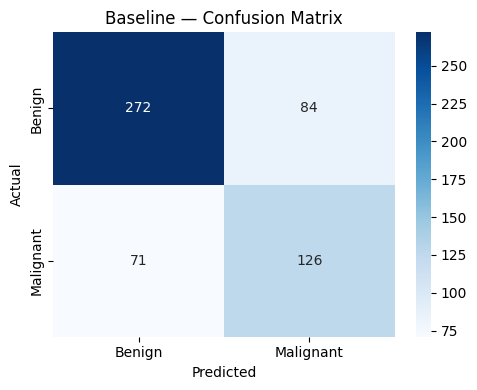

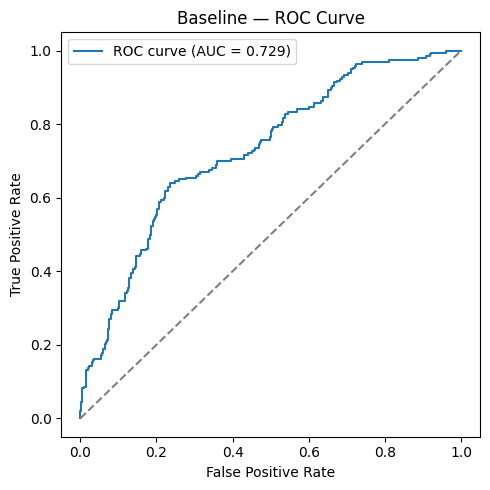

In [14]:
test_ds_baseline = MammogramDataset(test_df, transform=get_eval_transforms())
test_loader_baseline = DataLoader(test_ds_baseline, batch_size=BATCH_SIZE, shuffle=False)

y_true, y_probs = collect_predictions(baseline_model, test_loader_baseline, "baseline")
metrics = compute_metrics(y_true, y_probs)

print("=== Baseline test performance ===")
for k in ["accuracy", "precision", "recall", "specificity", "f1", "roc_auc"]:
    marker = "  <-- emphasised (minimise false negatives)" if k == "recall" else ""
    print(f"{k:>12}: {metrics[k]:.4f}{marker}")

plot_confusion_matrix(metrics["confusion_matrix"], "Baseline — Confusion Matrix")
plot_roc_curve(y_true, y_probs, metrics["roc_auc"], "Baseline — ROC Curve")


## 10. Train the multimodal (image + clinical) model

Feature-level fusion of the ResNet50 image embedding with an MLP-encoded
clinical vector (breast density, mass shape/margins, assessment).


In [15]:
_t0 = time.time()

encoder, clinical_cols = fit_clinical_encoder(train_df)

train_ds_mm = MultimodalMammogramDataset(train_df, encoder, clinical_cols, transform=get_train_transforms())
val_ds_mm = MultimodalMammogramDataset(val_df, encoder, clinical_cols, transform=get_eval_transforms())

train_loader_mm = DataLoader(
    train_ds_mm, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=True, persistent_workers=(NUM_WORKERS > 0),
)
val_loader_mm = DataLoader(
    val_ds_mm, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=True, persistent_workers=(NUM_WORKERS > 0),
)

multimodal_model, multimodal_ckpt = train_model(
    "multimodal", train_loader_mm, val_loader_mm,
    clinical_input_dim=train_ds_mm.clinical_feature_dim,
)
print(f"Multimodal training took {time.time() - _t0:.1f}s total")


/tmp/ipykernel_2090/3952286698.py:73: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


train:   0%|          | 0/39 [00:00<?, ?it/s]

eval:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 01/20 | train_loss=0.6688 train_auc=0.5768 | val_loss=0.6825 val_auc=0.5621 | 16.2s
  -> saved new best checkpoint (val_auc=0.5621)


train:   0%|          | 0/39 [00:00<?, ?it/s]

...

eval:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 18/20 | train_loss=0.2768 train_auc=0.9511 | val_loss=0.5987 val_auc=0.8262 | 15.4s


train:   0%|          | 0/39 [00:00<?, ?it/s]

eval:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 19/20 | train_loss=0.2564 train_auc=0.9575 | val_loss=0.6404 val_auc=0.8255 | 15.3s
Early stopping at epoch 19.
Multimodal training took 363.1s total


## 11. Evaluate the multimodal model and compare with the baseline

=== Multimodal test performance ===
    accuracy: 0.8264
   precision: 0.7886
      recall: 0.7005  <-- emphasised (minimise false negatives)
 specificity: 0.8961
          f1: 0.7419
     roc_auc: 0.9036


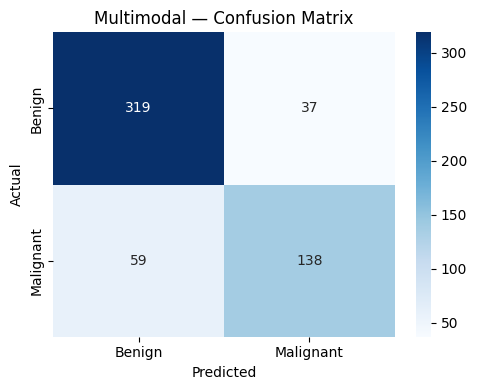

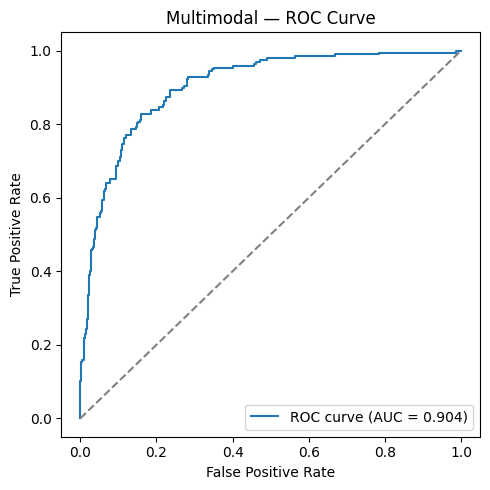

,accuracy,precision,recall,specificity,f1,roc_auc
Baseline (image-only),0.719711,0.600000,0.639594,0.764045,0.619165,0.728826
Multimodal (image+clinical),0.826401,0.788571,0.700508,0.896067,0.741935,0.903639


In [16]:
test_ds_mm = MultimodalMammogramDataset(test_df, encoder, clinical_cols, transform=get_eval_transforms())
test_loader_mm = DataLoader(test_ds_mm, batch_size=BATCH_SIZE, shuffle=False)

y_true_mm, y_probs_mm = collect_predictions(multimodal_model, test_loader_mm, "multimodal")
metrics_mm = compute_metrics(y_true_mm, y_probs_mm)

print("=== Multimodal test performance ===")
for k in ["accuracy", "precision", "recall", "specificity", "f1", "roc_auc"]:
    marker = "  <-- emphasised (minimise false negatives)" if k == "recall" else ""
    print(f"{k:>12}: {metrics_mm[k]:.4f}{marker}")

plot_confusion_matrix(metrics_mm["confusion_matrix"], "Multimodal — Confusion Matrix")
plot_roc_curve(y_true_mm, y_probs_mm, metrics_mm["roc_auc"], "Multimodal — ROC Curve")

comparison = pd.DataFrame({
    "Baseline (image-only)": {k: metrics[k] for k in ["accuracy","precision","recall","specificity","f1","roc_auc"]},
    "Multimodal (image+clinical)": {k: metrics_mm[k] for k in ["accuracy","precision","recall","specificity","f1","roc_auc"]},
}).T
comparison


## 12. Grad-CAM — visualising which mammogram regions drove predictions

Hooks the last convolutional block (`layer4`) of the baseline ResNet50 and
computes class-discriminative localisation maps.


In [17]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        logits = self.model(input_tensor)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        logits[:, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


def overlay_heatmap(image_tensor, cam, alpha=0.4):
    mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
    std = np.array(IMAGENET_STD).reshape(3, 1, 1)
    img = image_tensor.cpu().numpy() * std + mean
    img = np.clip(img.transpose(1, 2, 0), 0, 1)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    return np.clip((1 - alpha) * img + alpha * heatmap, 0, 1)


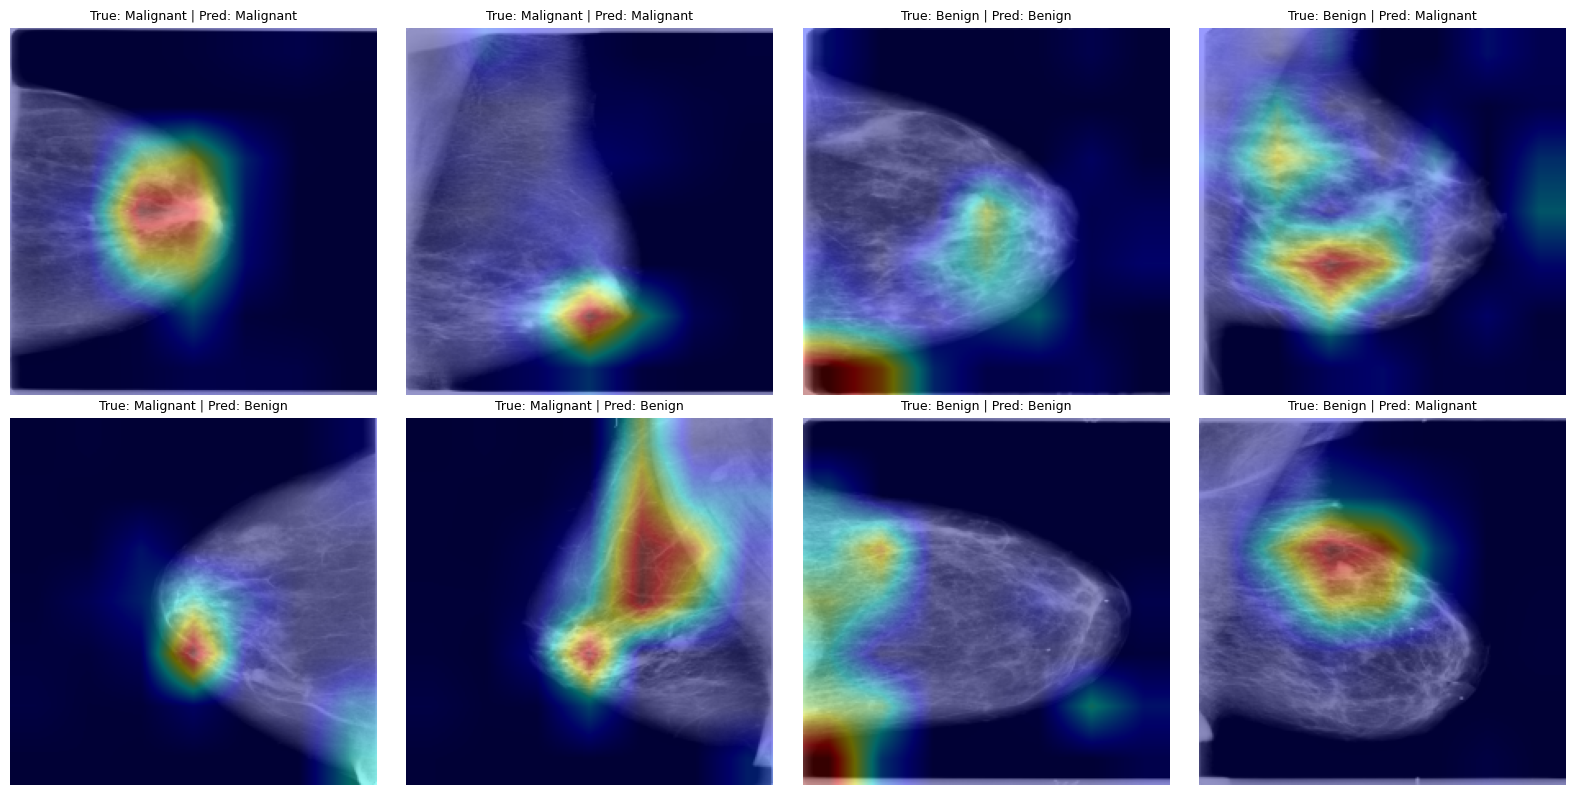

In [18]:
gradcam = GradCAM(baseline_model, baseline_model.backbone.layer4[-1])
class_names = {0: "Benign", 1: "Malignant"}

n = min(8, len(test_ds_baseline))
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(4 * ((n + 1) // 2), 8))
axes = axes.flatten()

for i in range(n):
    image, label = test_ds_baseline[i]
    input_tensor = image.unsqueeze(0).to(DEVICE)
    cam, pred_class = gradcam.generate(input_tensor)
    overlay = overlay_heatmap(image, cam)
    axes[i].imshow(overlay)
    axes[i].set_title(f"True: {class_names[int(label)]} | Pred: {class_names[pred_class]}", fontsize=9)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "gradcam_samples.png"), dpi=150)
plt.show()


## 13. SHAP — explaining the clinical feature contribution

We hold each sample's image fixed and vary only the clinical vector, so SHAP
attributes the change in predicted malignancy probability to the clinical
features (breast density, mass shape/margins, assessment) — the standard
approach for explaining one branch of a multimodal model.

**Performance note**: `KernelExplainer` calls the prediction function
thousands of times (nsamples-per-explained-sample × samples-explained). If
that function re-runs the full ResNet50 forward pass every time, this
section can generate tens of thousands of CNN forward passes and crash a
Colab runtime (GPU OOM or a session restart). Since the image is fixed
anyway, we compute its ResNet50 embedding **once**, and every SHAP
perturbation only runs the tiny clinical MLP + classifier head — the CNN
never runs again after that first pass.


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_2090/3188386905.py:44: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, to_explain, feature_names=feature_names, show=False)


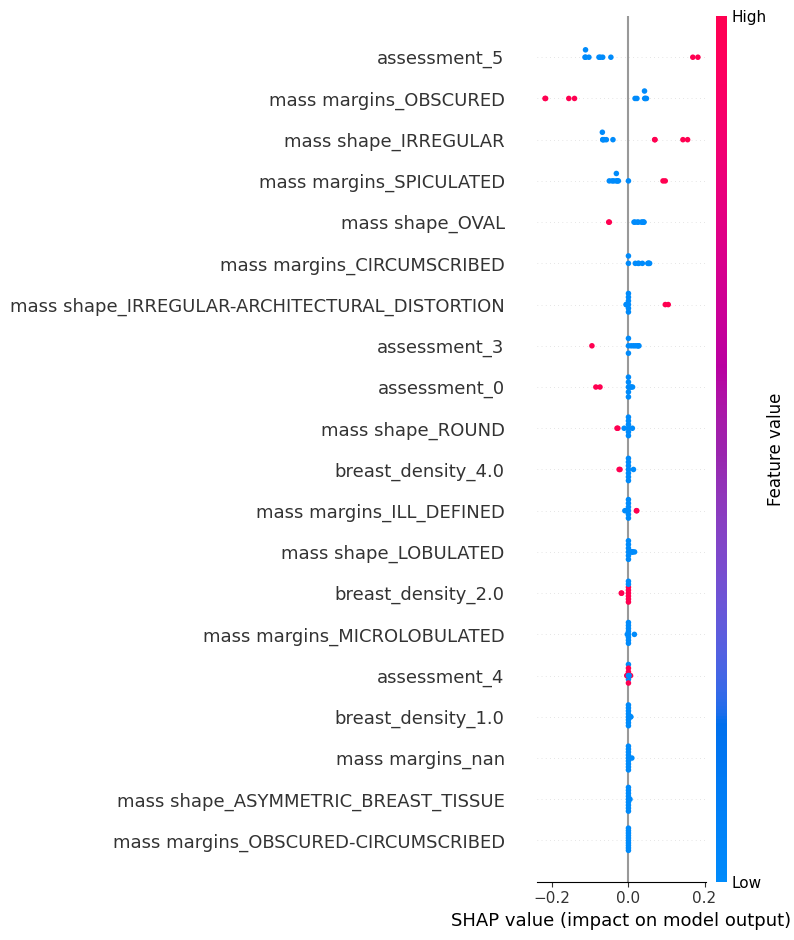

In [19]:
import shap

@torch.no_grad()
def build_prediction_fn(model, fixed_image):
    """Runs ResNet50 on the fixed image exactly once, then returns a
    lightweight function that reuses that cached embedding for every SHAP
    perturbation — avoiding thousands of repeated CNN forward passes.
    """
    model.eval()
    img_tensor = fixed_image.unsqueeze(0).to(DEVICE)
    image_embedding = torch.flatten(model.image_encoder(img_tensor), 1)  # (1, feat_dim), computed once

    def predict(clinical_batch: np.ndarray) -> np.ndarray:
        with torch.no_grad():
            clinical_tensor = torch.tensor(clinical_batch, dtype=torch.float32).to(DEVICE)
            n = clinical_tensor.shape[0]
            img_feats = image_embedding.repeat(n, 1)          # cheap: no CNN call
            clin_feats = model.clinical_encoder(clinical_tensor)
            fused = torch.cat([img_feats, clin_feats], dim=1)
            logits = model.classifier(fused)
            return torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    return predict

feature_names = encoder.get_feature_names_out(clinical_cols).tolist()

# Kept modest on purpose — SHAP's cost scales with background_size x
# nsamples x samples_explained. These defaults are already representative;
# raise them once you've confirmed this runs smoothly.
n_bg = min(30, len(test_ds_mm))
background = test_ds_mm.clinical_features[:n_bg]

fixed_image, _, _ = test_ds_mm[0]
predict_fn = build_prediction_fn(multimodal_model, fixed_image)

explainer = shap.KernelExplainer(predict_fn, background)

n_explain = min(10, len(test_ds_mm))
to_explain = test_ds_mm.clinical_features[:n_explain]
# A bounded nsamples instead of "auto" keeps runtime predictable regardless
# of how many one-hot clinical columns you end up with.
shap_values = explainer.shap_values(to_explain, nsamples=200)

plt.figure()
shap.summary_plot(shap_values, to_explain, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "shap_clinical_summary.png"), dpi=150, bbox_inches="tight")
plt.show()


## 14. Summary

**Final pipeline:**
`Dataset -> Data Pre-processing -> Feature Extraction -> Multimodal Feature Fusion -> Deep Learning Classifier -> Explainable AI -> Model Evaluation -> Clinical Decision Support System -> Decision Support for Radiologist`

- Baseline vs. multimodal metrics are compared in the table in Section 11.
- Grad-CAM (Section 12) shows which mammogram regions influenced each prediction.
- SHAP (Section 13) shows which clinical features (density, mass shape/margins, assessment) most influenced the multimodal model's output.
- Recall is reported alongside all other metrics and flagged explicitly, since minimising false negatives is the clinical priority for cancer screening.

**Limitation**: relies on a single public dataset (CBIS-DDSM), which may limit generalisability — future work could evaluate additional datasets and Vision Transformer architectures.
